<a href="https://colab.research.google.com/github/cara-jvr/mit-805-group-project/blob/unarine%2FMapReduce/Part_2_MapReduce.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**MIT 805 Big Data Project** <br>
Group 12 <br>
Unarine Ratshiedana (23985322)<br>
Cara Janse van Rensburg (18002189)

**1. Start-Up:** Creating Spark Session and importing required libraries

In [ ]:
from pyspark.sql import SparkSession

# creating a Spark Session Object
spark = (
    SparkSession.builder
    .appName("Big-Data-Project")
    .master("local[*]")
    .config("spark.driver.memory", "10g")
    .getOrCreate()
)
sc = spark.sparkContext
spark

In [ ]:
# import libraries
from pyspark.sql.functions import split, explode, col, desc, sum as _sum, when, count, to_timestamp, lit, datediff, timestamp_diff, unix_timestamp
from pyspark.sql import functions as F
import pyarrow.parquet as pq
import glob
import pandas as pd
import os
from google.colab import drive
import seaborn as sns
import matplotlib.pyplot as plt

**2. Loading the data**

In [ ]:
# reading files from Google Drive
drive.mount('/content/drive')
file_path = "drive/MyDrive/Big_data_project/data"
os.listdir(file_path)

In [ ]:
df = spark.read.parquet(file_path)

**3. Dataset Characteristics**

In [ ]:
# Getting the column names and data types
df.printSchema()

In [ ]:
# number of rows
rows = df.count()
print(f"Number of rows: {rows/10**6} million")

In [ ]:
# size of compressed raw file
compressed_gb = 0

for root, dirs, files in os.walk(file_path):
    for file in files:
        if file.endswith(".parquet"):
            compressed_gb += os.path.getsize(os.path.join(root, file))

total_gb = compressed_gb / (1024**3)

print(f"Total dataset size: {total_gb:.2f} GB")

In [ ]:
# size of uncompressed raw file

def get_parquet_uncompressed_size(file_path):
  metadata = pq.read_metadata(file_path)
  total_bytes = sum(metadata.row_group(i).total_byte_size for i in range(metadata.num_row_groups))
  return total_bytes


total_uncompressed_bytes = 0
file_count = 0


for root, dirs, files in os.walk(file_path):
    for file in files:
        if file.endswith('.parquet') or file.endswith('.parq'):
            full_path = os.path.join(root, file)


            uncompressed_bytes = get_parquet_uncompressed_size(full_path)
            total_uncompressed_bytes += uncompressed_bytes
            file_count += 1
            size_in_gb = uncompressed_bytes / (1024 ** 3)

total_uncompressed_gb = total_uncompressed_bytes / (1024 ** 3)

print(f"Total Parquet Files Found: {file_count}")
print(f"Total Uncompressed Size:   {total_uncompressed_gb:.4f} GB")

In [ ]:
df.limit(1).show()

In [ ]:
#Data date range
df.select(
    F.min("pickup_datetime"),
    F.max("pickup_datetime")
).show()

**4. Data Quality Analysis & Data Cleaning**

In [ ]:
#Missing Values
missing = df.select([
    count(when(col(c).isNull(), c)).alias(c)
    for c in df.columns
])

missing.show()

In [ ]:
# dropping originating_base_num and on_scene_datetime columns
df = df.drop("originating_base_num", "on_scene_datetime")

In [ ]:
# checking for duplicates
duplicates_df = (
    df.groupBy("hvfhs_license_num", "pickup_datetime", "dropoff_datetime","PULocationID", "DOLocationID", "trip_miles")
    .count()
    .filter(col("count") > 1)
)

duplicates_df.count()

In [ ]:
duplicates_df.limit(1).show()

In [ ]:
# dropping duplicates
df_dedup = df.dropDuplicates(["hvfhs_license_num", "pickup_datetime", "dropoff_datetime","PULocationID", "DOLocationID", "trip_miles"])
# dropping columns that are not needed
df_dedup = df_dedup.drop("dispatching_base_num", "request_datetime", "shared_request_flag", "shared_match_flag", "access_a_ride_flag")

In [ ]:
# invalid Trip duration
df_dedup = df_dedup.withColumn(
    "trip_seconds",
     unix_timestamp(col("dropoff_datetime")) - unix_timestamp(col("pickup_datetime"))
)
df_dedup.filter(col("trip_seconds") <= 0).count()

In [ ]:
# removing the above invalid trips
df_dedup = df_dedup.filter(col("trip_seconds") > 0)

In [ ]:
# ensuring that trip_time corresponds to (dropoff_datetime - pickup_datetime) within 1 second
df_dedup = df_dedup.withColumn(
    "seconds_diff",
     (col("trip_time") - col("trip_seconds"))
)
df_dedup = df_dedup.withColumn("absolute_diff", F.abs(df_dedup["seconds_diff"]))
df_dedup.filter((col("absolute_diff")) >1).count()

In [ ]:
# removing more incorrect trip times
df_dedup = df_dedup.filter((col("absolute_diff")) <=1)

In [ ]:
# base passenger fare must also be positive
df_dedup = df_dedup.filter(col("base_passenger_fare") > 0)

In [ ]:
# dropping the above create columns, as they are not needed going further
df_dedup = df_dedup.drop("seconds_diff", "absolute_diff")

In [ ]:
#df_dedup.describe().show()

In [ ]:
# outliers (Using Interquartile Range method)
def IQR_outlier_removal(df, column_name):
  q1, q3 = df.approxQuantile(column_name, [0.25, 0.75], 0.05)
  iqr = q3 - q1
  lower_val = q1 - 1.5 * iqr
  upper_val = q3 + 1.5 * iqr
  clean_df = df.filter((col(column_name) >= lower_val) & (col(column_name) <= upper_val))
  return clean_df

df_clean1 = IQR_outlier_removal(df_dedup, "trip_time")

In [ ]:
df_clean2 = IQR_outlier_removal(df_clean1, "trip_miles")
df_clean2.count()

In [ ]:
# bias
# checking which pick-up locations are not attended to
PULocation_counts = df_clean2.groupBy("PULocationID").count()
PULocation_counts.orderBy(F.col("count").asc()).show(10)

In [ ]:
#checking which drop off zones are not get attended to
DOLocation_counts = df_clean2.groupBy("DOLocationID").count()
DOLocation_counts.orderBy(F.col("count").asc()).show(10)

In [ ]:
# check for operational time bias
df_clean2 = df_clean2.withColumn("Year", F.year("pickup_datetime")) \
              .withColumn("Month", F.month("pickup_datetime")) \
              .withColumn("Hour", F.hour("pickup_datetime")) \
              .withColumn("weekday_name", F.date_format("pickup_datetime", "EEEE"))

In [ ]:
df_clean2.groupBy("weekday_name").count().orderBy("count", ascending=False).show()

**5. Exploratory Data Analysis**

In [ ]:
Year_df = df_clean2.groupBy("Year").count().toPandas()


plt.figure(figsize=(8, 5))
sns.barplot(x="Year", y="count", data=Year_df)
plt.title("Count Plot of Year")
plt.xticks(rotation=45)
plt.show()

In [ ]:
Month_df = df_clean2.groupBy("Month").count().toPandas()


plt.figure(figsize=(8, 5))
sns.barplot(x="Month", y="count", data=Month_df)
plt.title("Count Plot of Month")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# year month
df_clean2 = df_clean2.withColumn(
    "Year_Month",
    F.concat_ws("_", F.col("Year"), F.lpad(F.col("Month"), 2, "0"))
)
Year_month_order = ["2024_01", "2024_02", "2024_03", "2024_04", "2024_05", "2024_06", "2024_07", "2024_08", "2024_09", "2024_10", "2024_11", "2024_12",
                    "2025_01", "2025_02", "2025_03", "2025_04", "2025_05", "2025_06", "2025_07", "2025_08", "2025_09", "2025_10", "2025_11", "2025_12"]
Year_Month_df = df_clean2.groupBy("Year_Month").count().toPandas()


plt.figure(figsize=(8, 5))
sns.barplot(x="Year_Month", y="count", data=Year_Month_df, order = Year_month_order)
plt.title("Count Plot of Year_Month")
plt.xticks(rotation=45)
plt.show()

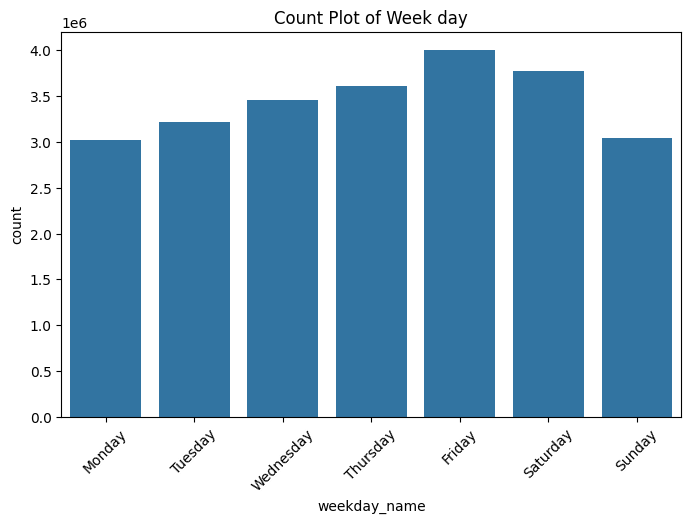

In [44]:
Day_df = df_clean2.groupBy("weekday_name").count().toPandas()
order_days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

plt.figure(figsize=(8, 5))
sns.barplot(x="weekday_name", y="count", data=Day_df, order=order_days)
plt.title("Count Plot of Week day")
plt.xticks(rotation=45)
plt.show()

In [ ]:
heatmap_df = df_clean2.groupBy("weekday_name", "Hour").count()

pandas = heatmap_df.toPandas()

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

pandas["weekday_name"] = pd.Categorical(pandas["weekday_name"], categories=day_order, ordered=True)

pivot_df = pandas.pivot(index="weekday_name", columns="Hour", values="count").fillna(0)

plt.figure(figsize=(14, 6))
sns.heatmap(
    pivot_df,
    cmap="coolwarm",
    annot=False,
    fmt="g",
    linewidths=0.5
)

plt.title("Heatmap showing count distriubtion by Day and Hour")
plt.xlabel("Hour of Day (0-23)")
plt.ylabel("Day of Week")
plt.tight_layout()
plt.show()


In [ ]:
# correlation map
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation

cols_corr = ["base_passenger_fare", "tips", "driver_pay", "trip_time", "trip_miles"]

assembler = VectorAssembler(inputCols=cols_corr, outputCol="features")
vector_df = assembler.transform(df_clean2).select("features")

mat = Correlation.corr(vector_df, "features").head()
spark_mat = mat[0].toArray()

corr_pd_df = pd.DataFrame(spark_mat, columns=cols_corr, index=cols_corr)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_pd_df, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
plt.title("Correlation Matrix Heatmap")
plt.show()


## Part 2 Map reduce

In [ ]:
# Mapping Phase
from pyspark.sql import functions as F

mapped_df = (
    df_clean2
    .withColumn("hour", F.hour("pickup_datetime"))
    .withColumn("weekday", F.date_format("pickup_datetime", "EEEE"))
    .select(
        "PULocationID",
        "base_passenger_fare",
        "trip_miles",
        "hour",
        "weekday"
    )
)

In [ ]:
# Shuffle Phase
grouped_df = mapped_df.groupBy("PULocationID")

In [ ]:
# Reduce Phase
location_summary = (
    grouped_df
    .agg(
        F.count("*").alias("total_trips"),
        F*sum("base_passenger_fare").alias("*otal_revenue"),
        F.avg("bas*_passenger_fare").alias("avg_fare"*,
        F.avg("trip_miles").alia*("avg_distance")
    )
)

## Spark Transformations and Actions

In [ ]:
# Transformations
withColumn()
select()
fi*ter()
groupBy()
agg()
orderBy()

In [ ]:
# Actions
*how()
count*)
collect*)
toPandas()

In [ ]:
#Shuffle Operation
group*y("PULocationID")

In [ ]:
#Spark UI
location_summary.show()

In [ ]:
# DAG Visualization
location_summary.*xplain(True)

In [ ]:
# Results and Technical Interpretation
top_locations = (
    locati*n_summary
    .orderBy(F.desc("tot*l_revenue"))
    .limit(10)
)

top*locations*show()

## Visualizations

In [ ]:
#Top 10 Revenue Generating Pickup Locations
top_locations_pd = top_locations.t*Pandas()

sns*barplot(
*  *data=top_locations_pd,
*  *x*"PULocationID",
    y="total_reven*e"
)
*

In [ ]:
#Trips by Hour
hourly = (
*  *df_clean2
*  *.*roupBy(F.hour("pickup_datetime").a*ias("hour"))
    .count()
*   .orderBy("hour")
*

sns.lineplot(
*  *data=hourly.toPandas(),
    x="hou*",
    y*"count"
)

In [ ]:
#Day vs Hour Heatmap
# we have this in our part one

In [ ]:
# Revenue vs Distance Correlation
sns.scatterplot(
    data=sample_*d,
    x="trip_miles",
*   y="base_passenger_fare"
)
*